In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [88]:
#importing all datasets
february = pd.read_csv('original_datasets/CRMLSSold202502_filled.csv')
march = pd.read_csv('original_datasets/CRMLSSold202503_filled.csv')
april = pd.read_csv('original_datasets/CRMLSSold202504_filled.csv')
may = pd.read_csv('original_datasets/CRMLSSold202505_filled.csv')
june = pd.read_csv('original_datasets/CRMLSSold202506_filled.csv')
july = pd.read_csv('original_datasets/CRMLSSold202507_filled.csv')
august = pd.read_csv('original_datasets/CRMLSSold202508_filled-2.csv')
september = pd.read_csv('original_datasets/CRMLSSold202509.csv')

C:\Users\jueeh\AppData\Local\Temp\ipykernel_15652\3343253333.py:6: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  june = pd.read_csv('original_datasets/CRMLSSold202506_filled.csv')


In [89]:
combined_dataset = pd.concat([february, march, april, may, june, july, august, september], ignore_index=True)
combined_dataset

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled
0,RanchoSoutheast,RanchoSoutheast,NaN,True,NaN,NaN,NaN,60000.0,526199946,cmark1018@yahoo.com,...,NaN,False,NaN,NaN,92307,0.0,28000.0,NaN,False,False
1,InlandValleys,InlandValleys,NaN,False,NaN,NaN,NaN,550000.0,525585060,mozcorona@aol.com,...,NaN,False,NaN,NaN,92553,0.0,39640.0,NaN,False,False
2,SanDiego,SanDiego,NaN,False,NaN,NaN,False,880000.0,497696903,lenskab@gmail.com,...,NaN,False,2.0,NaN,91942,NaN,NaN,NaN,False,False
3,SanDiego,SanDiego,NaN,False,NaN,NaN,False,875000.0,497696407,lenskab@gmail.com,...,NaN,False,2.0,NaN,91942,NaN,NaN,NaN,False,False
4,SanDiego,SanDiego,NaN,False,NaN,NaN,False,849000.0,486616176,lenskab@gmail.com,...,NaN,False,2.0,NaN,91942,NaN,NaN,NaN,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178502,InlandValleys,InlandValleys,NaN,True,NaN,NaN,NaN,24800.0,1018638495,javi4uhome@gmail.com,...,NaN,False,NaN,NaN,92230,0.0,5663.0,NaN,NaN,NaN
178503,InlandValleys,InlandValleys,NaN,True,NaN,NaN,NaN,249900.0,1016742369,jerryavila@allnationsontario.com,...,NaN,False,NaN,NaN,92365,0.0,4356000.0,NaN,NaN,NaN
178504,SierraNorthValley,SierraNorthValley,NaN,True,NaN,NaN,NaN,115000.0,1014482709,blake@virtualhomesales.net,...,NaN,False,NaN,NaN,95916,0.0,418176.0,NaN,NaN,NaN
178505,Oroville,Oroville,NaN,True,NaN,NaN,NaN,117000.0,1014210894,steffan@steffanblaser.com,...,NaN,False,NaN,NaN,95916,0.0,152460.0,NaN,NaN,NaN


In [90]:
print(combined_dataset.shape)
combined_dataset.info()
combined_dataset.describe(include='all')
combined_dataset.isna().mean().sort_values(ascending=False).head(20)

(178507, 80)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178507 entries, 0 to 178506
Data columns (total 80 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   BuyerAgentAOR                 178431 non-null  object 
 1   ListAgentAOR                  178431 non-null  object 
 2   Flooring                      105072 non-null  object 
 3   ViewYN                        160563 non-null  object 
 4   WaterfrontYN                  98 non-null      object 
 5   BasementYN                    2915 non-null    object 
 6   PoolPrivateYN                 158865 non-null  object 
 7   OriginalListPrice             177943 non-null  float64
 8   ListingKey                    178507 non-null  int64  
 9   ListAgentEmail                177841 non-null  object 
 10  CloseDate                     178507 non-null  object 
 11  ClosePrice                    178505 non-null  float64
 12  ListAgentFirstName            1

MiddleOrJuniorSchoolDistrict    1.000000
CoveredSpaces                   1.000000
AboveGradeFinishedArea          1.000000
ElementarySchoolDistrict        1.000000
FireplacesTotal                 1.000000
TaxYear                         0.999457
WaterfrontYN                    0.999451
BusinessType                    0.997625
TaxAnnualAmount                 0.996667
BelowGradeFinishedArea          0.995227
BasementYN                      0.983670
BuilderName                     0.961368
LotSizeDimensions               0.946349
CoBuyerAgentFirstName           0.918138
ElementarySchool                0.891130
MiddleOrJuniorSchool            0.890626
BuildingAreaTotal               0.868621
HighSchool                      0.857311
CoListAgentFirstName            0.789470
CoListAgentLastName             0.789050
dtype: float64

In [91]:
#drop columns with >75% missing values, as well as columns with zero variance
threshold = 0.75
cols_to_drop = combined_dataset.columns[combined_dataset.isna().mean() > threshold].tolist()
combined_dataset = combined_dataset.drop(columns=cols_to_drop)

In [92]:
zero_variance_cols = combined_dataset.columns[combined_dataset.nunique() <= 1].tolist()
combined_dataset = combined_dataset[(combined_dataset['StateOrProvince'] == 'CA')&(combined_dataset['PropertyType'] == 'Residential') & (combined_dataset['PropertySubType'] == 'SingleFamilyResidence')]
zero_variance_cols = combined_dataset.columns[combined_dataset.nunique() <= 1].tolist()
combined_dataset = combined_dataset.drop(columns=zero_variance_cols)

more_columns_to_drop = ['ListingKey', 'ListingKeyNumeric', 'ListingId', 'UnparsedAddress', 'ListPrice', 'OriginalListPrice', 'DaysOnMarket', 'AssociationFee', 'AssociationFeeFrequency', 'HighSchoolDistrict', 'BuyerAgentAOR', 'ListAgentAOR', 'BuyerOfficeAOR', 'ListAgentEmail', 'ListAgentFirstName', 'ListAgentLastName', 'ListAgentFullName', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'BuyerAgentMlsId', 'ListOfficeName', 'BuyerOfficeName', 'SubdivisionName', 'Levels']
combined_dataset = combined_dataset.drop(columns=more_columns_to_drop)
combined_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 89836 entries, 2 to 178499
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Flooring                  58108 non-null  object 
 1   ViewYN                    81578 non-null  object 
 2   PoolPrivateYN             82804 non-null  object 
 3   CloseDate                 89836 non-null  object 
 4   ClosePrice                89836 non-null  float64
 5   Latitude                  89831 non-null  float64
 6   Longitude                 89831 non-null  float64
 7   LivingArea                89783 non-null  float64
 8   MLSAreaMajor              76704 non-null  object 
 9   CountyOrParish            89836 non-null  object 
 10  AttachedGarageYN          79064 non-null  object 
 11  ParkingTotal              89835 non-null  float64
 12  LotSizeAcres              88274 non-null  float64
 13  YearBuilt                 89770 non-null  float64
 14  StreetNumb

In [93]:
#visualize missing data
!pip install missingno
import missingno as msno
#(combined_dataset.isna().mean() * 100).sort_values(ascending=False)

<Axes: >

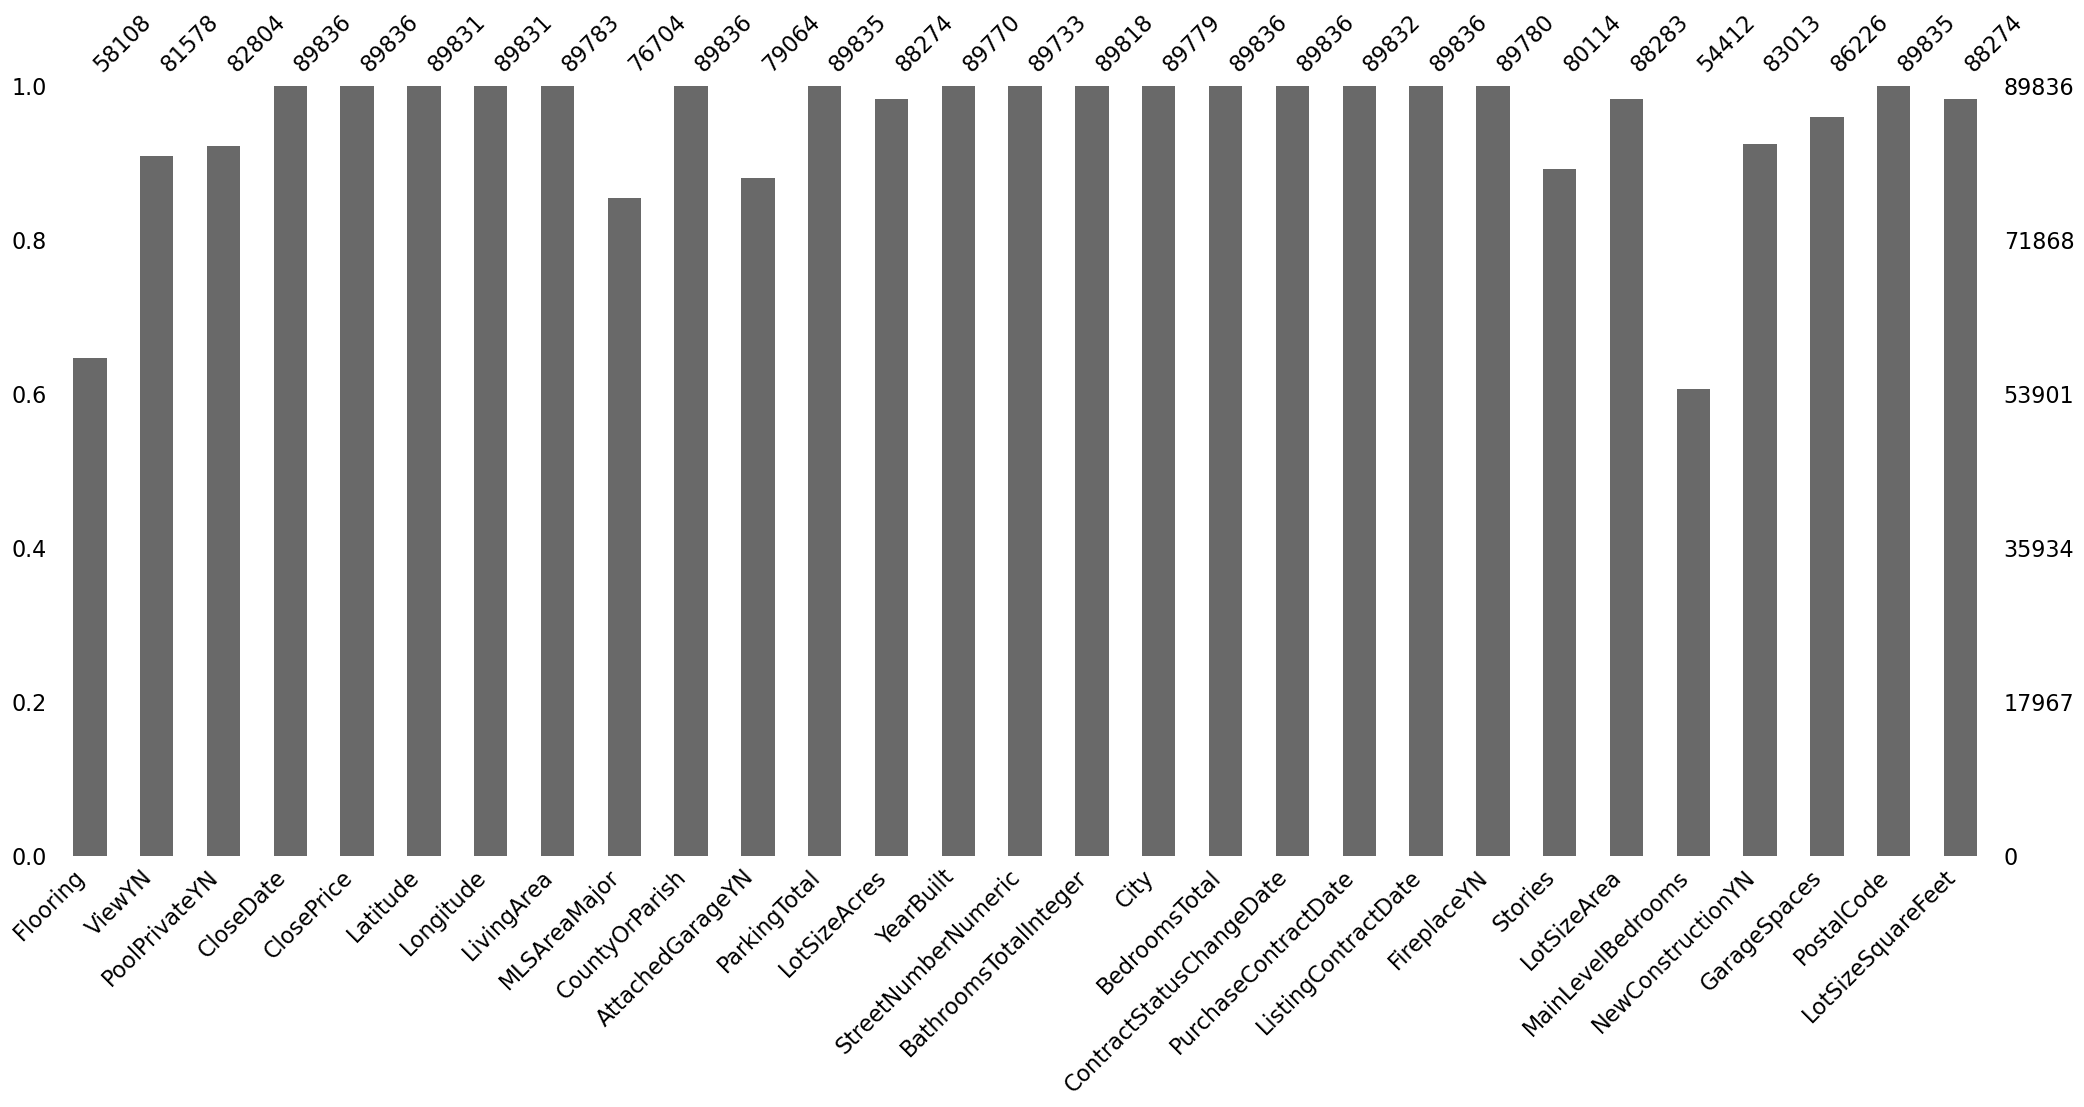

In [94]:
msno.bar(combined_dataset)

In [ ]:
combined_dataset = combined_dataset.drop(columns = ['Flooring', 'MLSAreaMajor'])#lots of NaNs, also very sparse info

<Axes: >

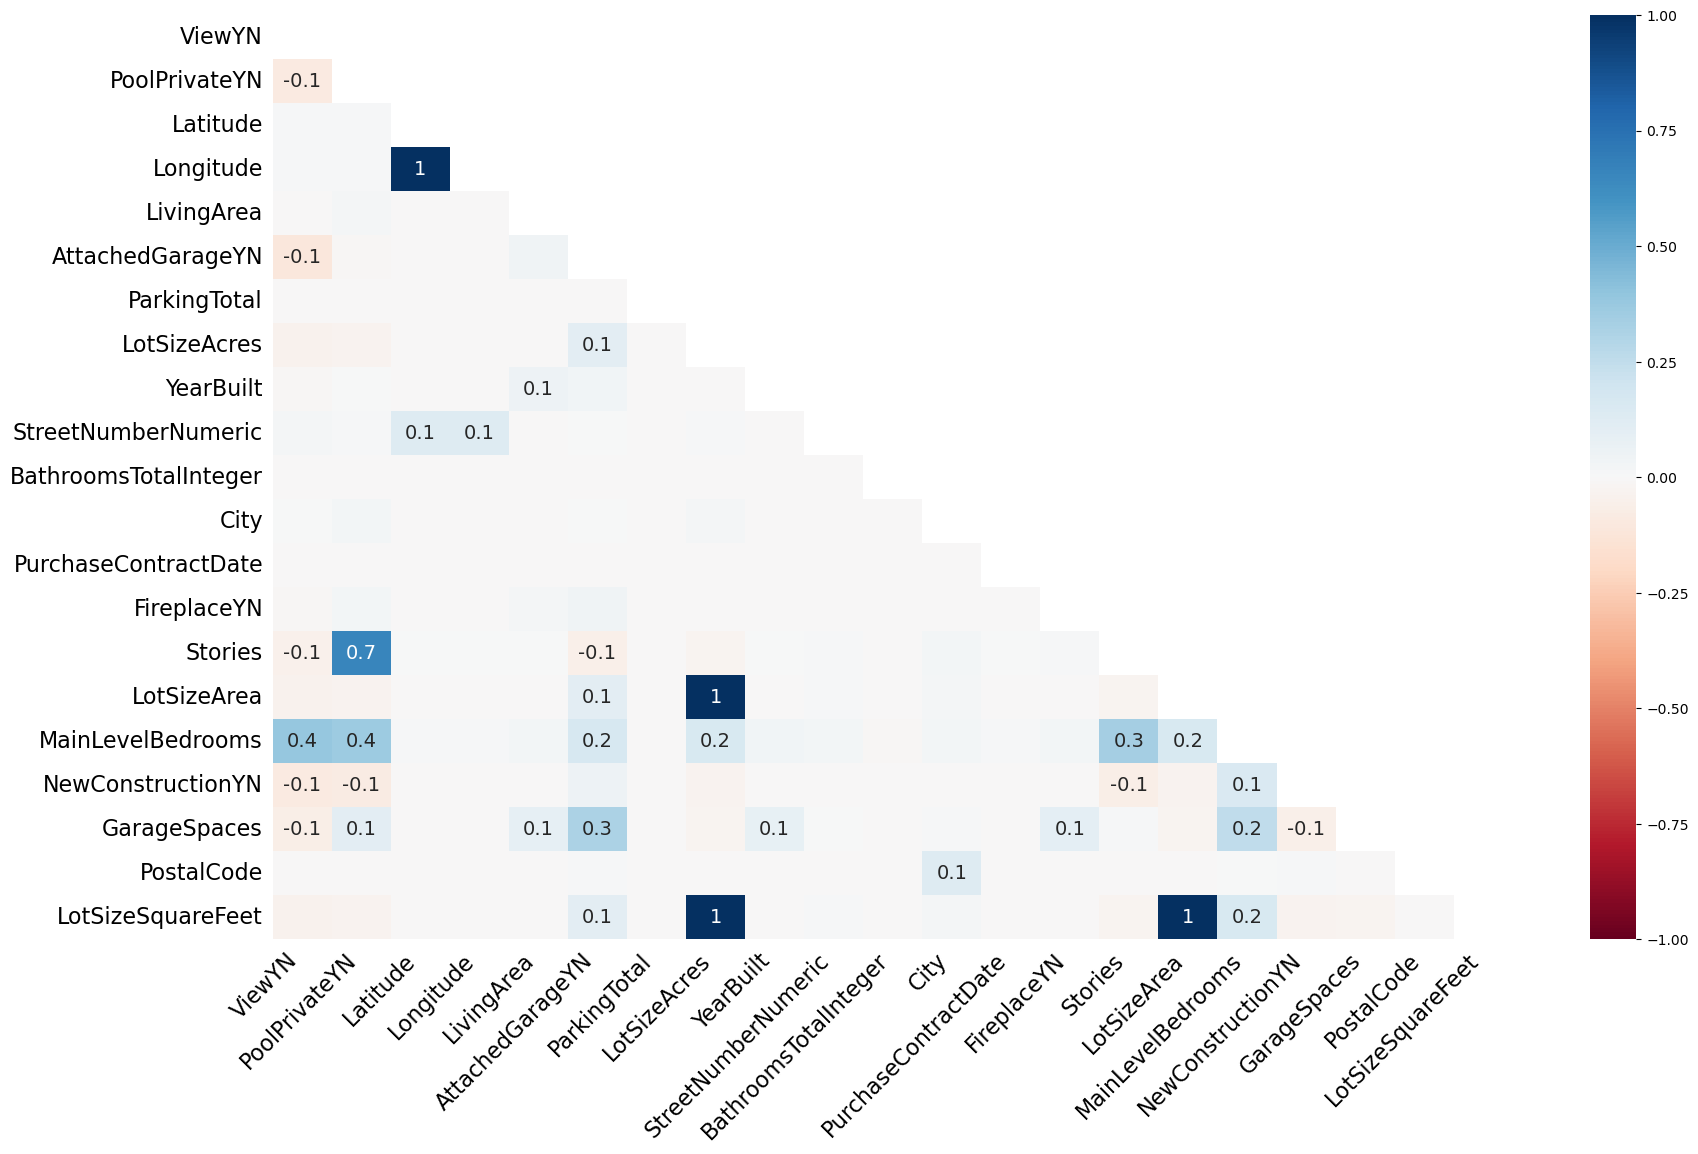

In [ ]:
msno.heatmap(combined_dataset) 
#notes: if latitute is missing, longitude is missing too. Stories and PoolPrivateYN also has a strong correlation. Otherwise, not strong correlations between missingness of different columns.

In [ ]:
#distribution visualization
#need to trim top and bottom 0.5% of outliers 
fig = px.histogram(combined_dataset, x='ClosePrice', nbins=30, title='Distribution of Close Price')
fig

In [108]:
close_price_bottom = combined_dataset['ClosePrice'].quantile(0.005)
close_price_top = combined_dataset['ClosePrice'].quantile(0.995)
combined_dataset = combined_dataset[(combined_dataset['ClosePrice'] >= close_price_bottom) & (combined_dataset['ClosePrice'] <= close_price_top)]
fig_2 = px.histogram(combined_dataset, x='ClosePrice', nbins=30, title='Distribution of Close Price (Trimmed)')
fig_2

In [119]:
combined_dataset['ClosePrice'].describe() #minimum is 190k, median is 900k, maximum is 8.5M

#correlations- need to do data conversions first
combined_dataset['StreetNumberNumeric'] #street number numeric won't give us any information about close price- drop it
combined_dataset = combined_dataset.drop(columns=['StreetNumberNumeric'])

In [123]:
boolean_columns = ['ViewYN', 'PoolPrivateYN', 'AttachedGarageYN', 'FireplaceYN', 'NewConstructionYN']
combined_dataset[boolean_columns].isna().sum()
for col in boolean_columns:
    print(combined_dataset[col].value_counts(dropna=False))


#explore why these columns have missing values- first need to do Date time conversions

ViewYN
True     49271
False    31443
NaN       8251
Name: count, dtype: int64
PoolPrivateYN
False    68135
True     13950
NaN       6880
Name: count, dtype: int64
AttachedGarageYN
True     65648
False    12893
NaN      10424
Name: count, dtype: int64
FireplaceYN
True     64701
False    24213
NaN         51
Name: count, dtype: int64
NewConstructionYN
False    79077
NaN       6802
True      3086
Name: count, dtype: int64


In [126]:
date_columns = ['PurchaseContractDate', 'ListingContractDate', 'ContractStatusChangeDate', 'CloseDate']
combined_dataset[date_columns] = combined_dataset[date_columns].apply(pd.to_datetime, errors='coerce')
combined_dataset[date_columns].info()

<class 'pandas.core.frame.DataFrame'>
Index: 88965 entries, 2 to 178499
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   PurchaseContractDate      88961 non-null  datetime64[ns]
 1   ListingContractDate       88965 non-null  datetime64[ns]
 2   ContractStatusChangeDate  88965 non-null  datetime64[ns]
 3   CloseDate                 88965 non-null  datetime64[ns]
dtypes: datetime64[ns](4)
memory usage: 3.4 MB


In [ ]:
#Features of the house itself
print(combined_dataset[['LivingArea', 'ParkingTotal', 'BathroomsTotalInteger', 'BedroomsTotal', 'Stories', 'MainLevelBedrooms', 'GarageSpaces', 'ClosePrice']].corr()['ClosePrice'].sort_values(ascending=False))
core_house_features = ['LivingArea', 'ParkingTotal', 'BathroomsTotalInteger', 'BedroomsTotal', 'Stories', 'MainLevelBedrooms', 'GarageSpaces']

#why are there so many mainlevelbedrooms missing?

combined_dataset[['MainLevelBedrooms', 'BedroomsTotal', 'Stories']] #i feel like BedroomsTotal has more influence on ClosePrice
combined_dataset['Stories'] = combined_dataset['Stories'].fillna(1)


ClosePrice               1.000000
LivingArea               0.601810
BathroomsTotalInteger    0.551401
BedroomsTotal            0.342692
Stories                  0.236247
GarageSpaces             0.059809
ParkingTotal             0.002635
MainLevelBedrooms       -0.084252
Name: ClosePrice, dtype: float64
LivingArea 40
ParkingTotal 1
BathroomsTotalInteger 18
BedroomsTotal 0
Stories 9524
MainLevelBedrooms 35077
GarageSpaces 3492


In [154]:
for feature in core_house_features:
    print(feature, combined_dataset[feature].isna().sum())

combined_dataset.loc[combined_dataset['GarageSpaces'].isna(), 'GarageSpaces'] = combined_dataset['ParkingTotal']

LivingArea 40
ParkingTotal 1
BathroomsTotalInteger 18
BedroomsTotal 0
Stories 0
MainLevelBedrooms 35077
GarageSpaces 3492


0.7566346315966953